In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [2]:
df = pd.DataFrame({
    "timestamp": ["2026-08-20 09:00:00", "2026-08-20 09:01:00", "2026-08-20 09:02:00", "2026-08-20 09:03:00"],
    "source": ["api", "db", "api", "worker"],
    "level": ["INFO", "ERROR", "WARN", "ERROR"],
    "duration_ms": ["120", "350", "bad", "80"],
    "bytes": [1024, 2048, 512, None],
    "msg": ["start", "timeout", "cache hit", "retry"]
})

display(df)

,timestamp,source,level,duration_ms,bytes,msg
0,2026-08-20 09:00:00,api,INFO,120,1024.0,start
1,2026-08-20 09:01:00,db,ERROR,350,2048.0,timeout
2,2026-08-20 09:02:00,api,WARN,bad,512.0,cache hit
3,2026-08-20 09:03:00,worker,ERROR,80,NaN,retry


In [3]:
clean_df = df.copy()
clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"], errors="coerce")
clean_df["duration_ms"] = pd.to_numeric(clean_df["duration_ms"], errors="coerce")
clean_df["bytes"] = pd.to_numeric(clean_df["bytes"], errors="coerce")
clean_df["is_error"] = clean_df["level"].eq("ERROR")
clean_df["hour"] = clean_df["timestamp"].dt.hour
clean_df["duration_bucket"] = pd.cut(
    clean_df["duration_ms"],
    bins=[0, 100, 200, 300, 500, np.inf],
    labels=["0-100", "100-200", "200-300", "300-500", "500+"],
    right=False
)

display(clean_df)
display("缺失统计：")
display(clean_df.isna().sum())

,timestamp,source,level,duration_ms,bytes,msg,is_error,hour,duration_bucket
0,2026-08-20 09:00:00,api,INFO,120.0,1024.0,start,False,9,100-200
1,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,True,9,300-500
2,2026-08-20 09:02:00,api,WARN,NaN,512.0,cache hit,False,9,NaN
3,2026-08-20 09:03:00,worker,ERROR,80.0,NaN,retry,True,9,0-100


'缺失统计：'

timestamp          0
source             0
level              0
duration_ms        1
bytes              1
msg                0
is_error           0
hour               0
duration_bucket    1
dtype: int64

In [4]:
error_rate = (
    clean_df
    .assign(duration_ms=clean_df["duration_ms"])
    .groupby("source", dropna=False)["is_error"]
    .mean()
    .sort_values(ascending=False)
)
print(error_rate)

q95 = clean_df["duration_ms"].quantile(0.95)
print("全局95分位:", q95)

source
db        1.0
worker    1.0
api       0.0
Name: is_error, dtype: float64
全局95分位: 327.0


,source,level,sample_count,avg_duration,median_duration,p95_duration
0,api,INFO,1,120.0,120.0,120.0
1,api,WARN,0,NaN,NaN,NaN
2,db,ERROR,1,350.0,350.0,350.0
3,worker,ERROR,1,80.0,80.0,80.0


level,ERROR,INFO
source,,
api,NaN,120.0
db,350.0,NaN
worker,80.0,NaN


hour
9    0.5
Name: error_rate, dtype: float64

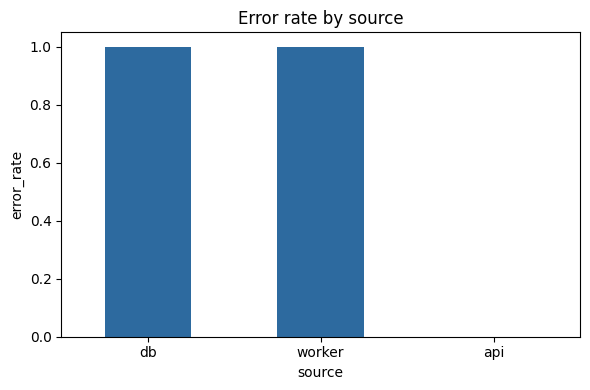

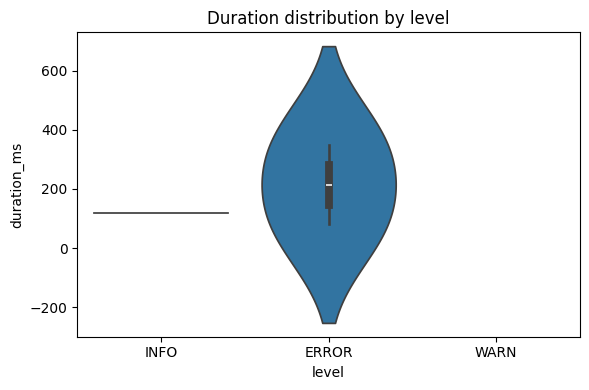

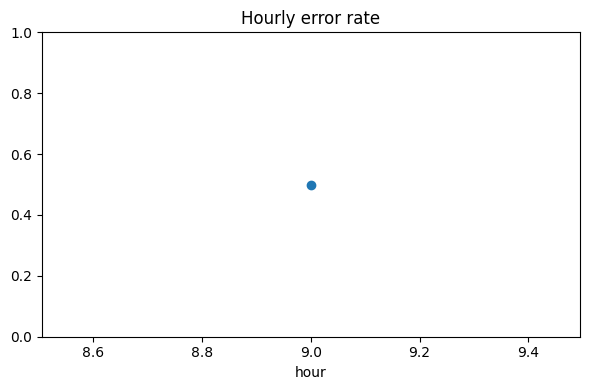

In [5]:
# 1) 按 source + level 的核心指标透视
summary = (
    clean_df.groupby(["source", "level"], as_index=False)
    .agg(
        sample_count=("duration_ms", "count"),
        avg_duration=("duration_ms", "mean"),
        median_duration=("duration_ms", "median"),
        p95_duration=("duration_ms", lambda s: s.quantile(0.95)),
    )
)
display(summary)

# 2) 构造 source x level 的透视表（便于横向比较）
pivot = clean_df.pivot_table(
    index="source",
    columns="level",
    values="duration_ms",
    aggfunc="mean",
)
display(pivot)

# 3) 按小时错误率（虽然本例只有一个小时，但先建立流程）
hourly = clean_df.groupby("hour")["is_error"].mean().rename("error_rate")
display(hourly)

# 4) 画三类图（每张图后面配一句结论）
# (a) source 错误率
err_by_source = clean_df.groupby("source")["is_error"].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
err_by_source.plot(kind="bar", color="#2d6a9f")
plt.title("Error rate by source")
plt.ylabel("error_rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# (b) level 与时延分布
plt.figure(figsize=(6, 4))
sns.violinplot(data=clean_df, x="level", y="duration_ms")
plt.title("Duration distribution by level")
plt.tight_layout()
plt.show()

# (c) 小时错误率趋势
plt.figure(figsize=(6, 4))
hourly.plot(kind="line", marker="o")
plt.title("Hourly error rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [6]:
slow_logs = (
    clean_df
    .loc[clean_df["duration_ms"] > q95]
    .sort_values("duration_ms", ascending=False)
)

display(slow_logs)

,timestamp,source,level,duration_ms,bytes,msg,is_error,hour,duration_bucket
1,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,True,9,300-500


In [7]:
source_q95 = (
    clean_df
    .groupby("source")["duration_ms"]
    .quantile(0.95)
    .rename("source_q95")
)

display(source_q95)

source
api       120.0
db        350.0
worker     80.0
Name: source_q95, dtype: float64

In [8]:
clean_df = clean_df.merge(
    source_q95,
    left_on="source",
    right_index=True,
    how="left"
)

display(
    clean_df[
        ["source", "duration_ms", "source_q95"]
    ]
)

,source,duration_ms,source_q95
0,api,120.0,120.0
1,db,350.0,350.0
2,api,NaN,120.0
3,worker,80.0,80.0


In [9]:
clean_df["is_source_slow"] = (
    clean_df["duration_ms"] > clean_df["source_q95"]
)

display(
    clean_df[
        ["source", "duration_ms", "source_q95", "is_source_slow"]
    ]
)

,source,duration_ms,source_q95,is_source_slow
0,api,120.0,120.0,False
1,db,350.0,350.0,False
2,api,NaN,120.0,False
3,worker,80.0,80.0,False


In [10]:
clean_df["is_global_slow"] = clean_df["duration_ms"] > q95

display(
    clean_df[
        [
            "source",
            "duration_ms",
            "is_error",
            "is_global_slow",
            "msg",
        ]
    ]
)

,source,duration_ms,is_error,is_global_slow,msg
0,api,120.0,False,False,start
1,db,350.0,True,True,timeout
2,api,NaN,False,False,cache hit
3,worker,80.0,True,False,retry


In [11]:
critical_logs = clean_df.loc[
    clean_df["is_error"] & clean_df["is_global_slow"]
]

display(
    critical_logs[
        ["timestamp", "source", "duration_ms", "msg"]
    ]
)

,timestamp,source,duration_ms,msg
1,2026-08-20 09:01:00,db,350.0,timeout


In [12]:
clean_df["priority"] = np.select(
    [
        clean_df["is_error"] & clean_df["is_global_slow"],
        clean_df["is_error"],
        clean_df["is_global_slow"],
    ],
    [
        "critical",
        "error",
        "slow",
    ],
    default="normal",
)

display(
    clean_df[
        [
            "source",
            "level",
            "duration_ms",
            "msg",
            "priority",
        ]
    ]
)

,source,level,duration_ms,msg,priority
0,api,INFO,120.0,start,normal
1,db,ERROR,350.0,timeout,critical
2,api,WARN,NaN,cache hit,normal
3,worker,ERROR,80.0,retry,error


In [13]:
clean_df["has_data_issue"] = clean_df["duration_ms"].isna()

display(
    clean_df[
        [
            "source",
            "level",
            "duration_ms",
            "msg",
            "priority",
            "has_data_issue",
        ]
    ]
)

valid_duration_logs = clean_df.loc[
    clean_df["duration_ms"].notna()
]

display(valid_duration_logs)

,source,level,duration_ms,msg,priority,has_data_issue
0,api,INFO,120.0,start,normal,False
1,db,ERROR,350.0,timeout,critical,False
2,api,WARN,NaN,cache hit,normal,True
3,worker,ERROR,80.0,retry,error,False


,timestamp,source,level,duration_ms,bytes,msg,is_error,hour,duration_bucket,source_q95,is_source_slow,is_global_slow,priority,has_data_issue
0,2026-08-20 09:00:00,api,INFO,120.0,1024.0,start,False,9,100-200,120.0,False,False,normal,False
1,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,True,9,300-500,350.0,False,True,critical,False
3,2026-08-20 09:03:00,worker,ERROR,80.0,NaN,retry,True,9,0-100,80.0,False,False,error,False


In [14]:
attention_logs = (
    clean_df
    .loc[
        (clean_df["priority"] != "normal")
        | clean_df["has_data_issue"]
    ]
    .sort_values(
        ["is_global_slow", "is_error"],
        ascending=[False, False],
    )
)

display(
    attention_logs[
        [
            "timestamp",
            "source",
            "level",
            "duration_ms",
            "msg",
            "priority",
            "has_data_issue",
        ]
    ]
)

,timestamp,source,level,duration_ms,msg,priority,has_data_issue
1,2026-08-20 09:01:00,db,ERROR,350.0,timeout,critical,False
3,2026-08-20 09:03:00,worker,ERROR,80.0,retry,error,False
2,2026-08-20 09:02:00,api,WARN,NaN,cache hit,normal,True


In [15]:
summary = pd.Series({
    "total_logs": len(clean_df),
    "error_logs": clean_df["is_error"].sum(),
    "global_slow_logs": clean_df["is_global_slow"].sum(),
    "critical_logs": (clean_df["priority"] == "critical").sum(),
    "data_issue_logs": clean_df["has_data_issue"].sum(),
    "error_rate": clean_df["is_error"].mean(),
})

display(summary)

total_logs          4.0
error_logs          2.0
global_slow_logs    1.0
critical_logs       1.0
data_issue_logs     1.0
error_rate          0.5
dtype: float64

In [16]:
priority_summary = (
    clean_df["priority"]
    .value_counts()
    .rename_axis("priority")
    .reset_index(name="log_count")
)

display(priority_summary)

,priority,log_count
0,normal,2
1,critical,1
2,error,1


In [17]:
output_columns = [
    "timestamp",
    "source",
    "level",
    "duration_ms",
    "bytes",
    "msg",
    "priority",
    "has_data_issue",
]

attention_logs[output_columns].to_csv(
    "attention_logs.csv",
    index=False,
    encoding="utf-8-sig",
)

exported_logs = pd.read_csv(
    "attention_logs.csv",
    parse_dates=["timestamp"],
)

display(exported_logs)

exported_logs.info()

,timestamp,source,level,duration_ms,bytes,msg,priority,has_data_issue
0,2026-08-20 09:01:00,db,ERROR,350.0,2048.0,timeout,critical,False
1,2026-08-20 09:03:00,worker,ERROR,80.0,NaN,retry,error,False
2,2026-08-20 09:02:00,api,WARN,NaN,512.0,cache hit,normal,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       3 non-null      datetime64[ns]
 1   source          3 non-null      object        
 2   level           3 non-null      object        
 3   duration_ms     2 non-null      float64       
 4   bytes           2 non-null      float64       
 5   msg             3 non-null      object        
 6   priority        3 non-null      object        
 7   has_data_issue  3 non-null      bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(4)
memory usage: 303.0+ bytes


In [18]:
display(exported_logs.shape)

display(exported_logs["duration_ms"].isna().sum())

display(
    exported_logs.loc[
        exported_logs["priority"] == "critical",
        ["source", "msg"],
    ]
)

(3, 8)

1

,source,msg
0,db,timeout


In [19]:
api_attention = exported_logs.loc[
    (exported_logs["source"] == "api")
    & ((exported_logs["priority"] != "normal")|(exported_logs["has_data_issue"])),
    [
        "timestamp",
        "level",
        "msg",
        "priority",
        "has_data_issue",
    ],
]

display(api_attention)

,timestamp,level,msg,priority,has_data_issue
2,2026-08-20 09:02:00,WARN,cache hit,normal,True


In [20]:
source_summary = (
    exported_logs
    .groupby("source")
    .agg(
        log_count=("source", "size"),
        avg_duration=("duration_ms", "mean"),
    )
    .reset_index()
)

display(source_summary)

,source,log_count,avg_duration
0,api,1,NaN
1,db,1,350.0
2,worker,1,80.0


In [21]:
source_summary = (
    exported_logs
    .groupby("source")
    .agg(
        log_count=("source", "size"),
        valid_duration_count=("duration_ms", "count"),
        avg_duration=("duration_ms", "mean"),
    )
    .reset_index()
)

display(source_summary)

source_summary["duration_complete_rate"] = (
    source_summary["valid_duration_count"]
    / source_summary["log_count"]
)

display(source_summary)

,source,log_count,valid_duration_count,avg_duration
0,api,1,0,NaN
1,db,1,1,350.0
2,worker,1,1,80.0


,source,log_count,valid_duration_count,avg_duration,duration_complete_rate
0,api,1,0,NaN,0.0
1,db,1,1,350.0,1.0
2,worker,1,1,80.0,1.0


In [22]:
incomplete_sources = (
    source_summary
    .loc[
        source_summary["duration_complete_rate"] < 1.0
    ]
    .sort_values(
        "duration_complete_rate",
        ascending=True,
    )
)

display(incomplete_sources)

,source,log_count,valid_duration_count,avg_duration,duration_complete_rate
0,api,1,0,NaN,0.0


# 第四周日志探索性数据分析报告

## 1. 描述性统计与统计直觉

In [23]:
import pandas as pd

sample = pd.Series([80, 90, 95, 100, 110, 1200])

summary = pd.Series(
    {
        "count": sample.count(),
        "mean": sample.mean(),
        "median": sample.median(),
        "std": sample.std(),
        "p25": sample.quantile(0.25),
        "p75": sample.quantile(0.75),
        "p95": sample.quantile(0.95),
        "max": sample.max(),
    }
)

print(summary.round(2))

count        6.00
mean       279.17
median      97.50
std        451.23
p25         91.25
p75        107.50
p95        927.50
max       1200.00
dtype: float64


In [24]:
q1 = sample.quantile(0.25)
q3 = sample.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("下界:", lower)
print("上界:", upper)
print("候选异常值:", sample[(sample < lower) | (sample > upper)].tolist())

Q1: 91.25
Q3: 107.5
IQR: 16.25
下界: 66.875
上界: 131.875
候选异常值: [1200]


In [25]:
df = clean_df.copy()

df["is_error"] = df["level"].eq("ERROR")

print(df.columns.tolist())

['timestamp', 'source', 'level', 'duration_ms', 'bytes', 'msg', 'is_error', 'hour', 'duration_bucket', 'source_q95', 'is_source_slow', 'is_global_slow', 'priority', 'has_data_issue']


In [26]:
source_quality = (
    df.groupby("source")
    .agg(
        sample_count=("source", "size"),
        error_count=("is_error", "sum"),
        error_rate=("is_error", "mean"),
        median_duration=("duration_ms", "median"),
        p95_duration=("duration_ms", lambda s: s.quantile(0.95)),
    )
    .sort_values(
        ["error_rate", "sample_count"],
        ascending=[False, False],
    )
)

source_quality.round(3)

,sample_count,error_count,error_rate,median_duration,p95_duration
source,,,,,
db,1,1,1.0,350.0,350.0
worker,1,1,1.0,80.0,80.0
api,2,0,0.0,120.0,120.0


### 按来源分析


观察：db：1 / 1 条报错，错误率 100%，耗时 350 ms。
worker：1 / 1 条报错，错误率 100%，耗时 80 ms。
api：0 / 2 条报错，错误率 0%，中位耗时 120 ms.
总样本量只有 4 条

**限制：总样本数量太少**

**下一步：增加日志样本量，然后重新统计结果**

In [27]:
logs_df = pd.DataFrame(
    {
        "timestamp": [
            "2026-08-20 09:00:00",
            "2026-08-20 09:01:00",
            "2026-08-20 09:02:00",
            "2026-08-20 09:03:00",
        ],
        "source": ["api", "db", "api", "worker"],
        "level": ["INFO", "ERROR", "WARN", "ERROR"],
        "duration_ms": ["120", "350", "bad", "80"],
        "bytes": [1024, 2048, 512, None],
        "msg": ["start", "timeout", "cache hit", "retry"],
    }
)

clean_df = logs_df.copy()

In [28]:
raw_df = logs_df.copy()

raw_df["duration_numeric"] = pd.to_numeric(
    raw_df["duration_ms"],
    errors="coerce",
)

duration_completeness = (
    raw_df.groupby("source")["duration_numeric"]
    .agg(
        valid_count="count",
        total_count="size",
    )
    .assign(
        completeness=lambda x: (
            x["valid_count"] / x["total_count"]
        )
    )
    .sort_values("completeness")
)

duration_completeness.round(3)

,valid_count,total_count,completeness
source,,,
api,1,2,0.5
db,1,1,1.0
worker,1,1,1.0


In [29]:
missing_by_level = (
    raw_df.assign(
        duration_missing=raw_df["duration_numeric"].isna()
    )
    .groupby("level")["duration_missing"]
    .agg(
        missing_count="sum",
        missing_rate="mean",
    )
    .sort_values("missing_rate", ascending=False)
)

missing_by_level

,missing_count,missing_rate
level,,
WARN,1,1.0
ERROR,0,0.0
INFO,0,0.0


In [30]:
clean_df = logs_df.copy()

clean_df["timestamp"] = pd.to_datetime(
    clean_df["timestamp"],
    errors="coerce",
)

clean_df["duration_ms"] = pd.to_numeric(
    clean_df["duration_ms"],
    errors="coerce",
)

clean_df["duration_was_missing"] = clean_df["duration_ms"].isna()
clean_df["bytes_was_missing"] = clean_df["bytes"].isna()

duration_median = clean_df["duration_ms"].median()

clean_df["duration_ms"] = clean_df["duration_ms"].fillna(
    duration_median
)

clean_df["bytes"] = clean_df["bytes"].fillna(0)

df = clean_df.copy()
df["is_error"] = df["level"].eq("ERROR")

print("耗时填充值：", duration_median)
print("耗时填充数量：", clean_df["duration_was_missing"].sum())
print("bytes 填充数量：", clean_df["bytes_was_missing"].sum())

耗时填充值： 120.0
耗时填充数量： 1
bytes 填充数量： 1


In [31]:
print(df.columns.tolist())

assert "duration_was_missing" in df.columns
assert "bytes_was_missing" in df.columns
assert "is_error" in df.columns

['timestamp', 'source', 'level', 'duration_ms', 'bytes', 'msg', 'duration_was_missing', 'bytes_was_missing', 'is_error']


In [32]:
observed_duration_df = df.loc[
    ~df["duration_was_missing"]
].copy()

print("清洗表行数：", len(df))
print("真实耗时行数：", len(observed_duration_df))

清洗表行数： 4
真实耗时行数： 3


In [33]:
observed_source_quality = (
    observed_duration_df.groupby("source")
    .agg(
        observed_count=("duration_ms", "size"),
        median_duration=("duration_ms", "median"),
        p95_duration=("duration_ms", lambda s: s.quantile(0.95)),
    )
)

observed_source_quality

,observed_count,median_duration,p95_duration
source,,,
api,1,120.0,120.0
db,1,350.0,350.0
worker,1,80.0,80.0


## 更大样本下的统计分析

In [34]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
sample_size = 500

large_df = pd.DataFrame(
    {
        "timestamp": pd.date_range(
            "2026-08-20 09:00:00",
            periods=sample_size,
            freq="min",
        ),
        "source": rng.choice(
            ["api", "db", "worker"],
            size=sample_size,
            p=[0.5, 0.3, 0.2],
        ),
    }
)

base_duration = large_df["source"].map(
    {
        "api": 100,
        "db": 220,
        "worker": 80,
    }
)

error_probability = large_df["source"].map(
    {
        "api": 0.05,
        "db": 0.12,
        "worker": 0.08,
    }
)

large_df["is_error"] = (
    rng.random(sample_size) < error_probability
)

large_df["level"] = np.where(
    large_df["is_error"],
    "ERROR",
    "INFO",
)

large_df["duration_ms"] = (
    base_duration
    + rng.normal(0, 25, sample_size)
    + large_df["is_error"] * rng.normal(180, 40, sample_size)
).clip(lower=1).round()

large_df["bytes"] = (
    500
    + large_df["duration_ms"] * 4
    + rng.normal(0, 250, sample_size)
).clip(lower=0).round()

large_df.head()

print("形状：")
print(large_df.shape)

print("\n各来源样本数：")
print(large_df["source"].value_counts())

print("\n各级别样本数：")
print(large_df["level"].value_counts())

形状：
(500, 6)

各来源样本数：
source
api       249
db        158
worker     93
Name: count, dtype: int64

各级别样本数：
level
INFO     456
ERROR     44
Name: count, dtype: int64


In [35]:
large_source_summary = (
    large_df.groupby("source")
    .agg(
        sample_count=("source", "size"),
        error_count=("is_error", "sum"),
        error_rate=("is_error", "mean"),
        mean_duration=("duration_ms", "mean"),
        median_duration=("duration_ms", "median"),
        p95_duration=(
            "duration_ms",
            lambda s: s.quantile(0.95),
        ),
    )
    .sort_values("error_rate", ascending=False)
)

large_source_summary.round(3)

,sample_count,error_count,error_rate,mean_duration,median_duration,p95_duration
source,,,,,,
db,158,22,0.139,246.563,227.0,409.35
worker,93,9,0.097,97.591,91.0,229.20
api,249,13,0.052,108.169,99.0,201.20


In [36]:
source_duration = large_df.groupby("source")["duration_ms"]

source_q1 = source_duration.transform(
    lambda s: s.quantile(0.25)
)

source_q3 = source_duration.transform(
    lambda s: s.quantile(0.75)
)

source_iqr = source_q3 - source_q1
source_iqr_upper = source_q3 + 1.5 * source_iqr

large_df["source_iqr_upper"] = source_iqr_upper

large_df["is_source_iqr_outlier"] = (
    large_df["duration_ms"] > large_df["source_iqr_upper"]
)

In [37]:
iqr_summary = (
    large_df.groupby("source")
    .agg(
        sample_count=("source", "size"),
        iqr_outlier_count=("is_source_iqr_outlier", "sum"),
        iqr_outlier_rate=("is_source_iqr_outlier", "mean"),
        error_count=("is_error", "sum"),
        error_rate=("is_error", "mean"),
    )
)

iqr_summary.round(3)

,sample_count,iqr_outlier_count,iqr_outlier_rate,error_count,error_rate
source,,,,,
api,249,13,0.052,13,0.052
db,158,20,0.127,22,0.139
worker,93,9,0.097,9,0.097


In [38]:
pd.crosstab(
    large_df["is_error"],
    large_df["is_source_iqr_outlier"],
    margins=True,
)

is_source_iqr_outlier,False,True,All
is_error,,,
False,456,0,456
True,2,42,44
All,458,42,500


In [39]:
comparison = pd.crosstab(
    large_df["is_error"],
    large_df["is_source_iqr_outlier"],
    rownames=["is_error"],
    colnames=["is_iqr_outlier"],
    margins=True,
)

comparison

is_iqr_outlier,False,True,All
is_error,,,
False,456,0,456
True,2,42,44
All,458,42,500


In [40]:
error_coverage = 42 / 44
outlier_error_share = 42 / 42

print("IQR 对 ERROR 的覆盖率：", error_coverage)
print("IQR 异常中的 ERROR 占比：", outlier_error_share)

IQR 对 ERROR 的覆盖率： 0.9545454545454546
IQR 异常中的 ERROR 占比： 1.0


In [41]:
missed_errors = large_df.loc[
    large_df["is_error"]
    & ~large_df["is_source_iqr_outlier"],
    [
        "timestamp",
        "source",
        "duration_ms",
        "source_iqr_upper",
        "level",
    ],
]

missed_errors

,timestamp,source,duration_ms,source_iqr_upper,level
54,2026-08-20 09:54:00,db,298.0,312.0,ERROR
119,2026-08-20 10:59:00,db,271.0,312.0,ERROR


In [42]:
overall_correlation = large_df[
    ["duration_ms", "bytes"]
].corr(method="pearson")

overall_correlation.round(3)

,duration_ms,bytes
duration_ms,1.000,0.818
bytes,0.818,1.000


In [43]:
correlation_by_source = (
    large_df.groupby("source")
    .apply(
        lambda group: group["duration_ms"].corr(
            group["bytes"]
        ),
        include_groups=False,
    )
    .rename("duration_bytes_correlation")
)

correlation_by_source.round(3)

source
api       0.655
db        0.748
worker    0.640
Name: duration_bytes_correlation, dtype: float64

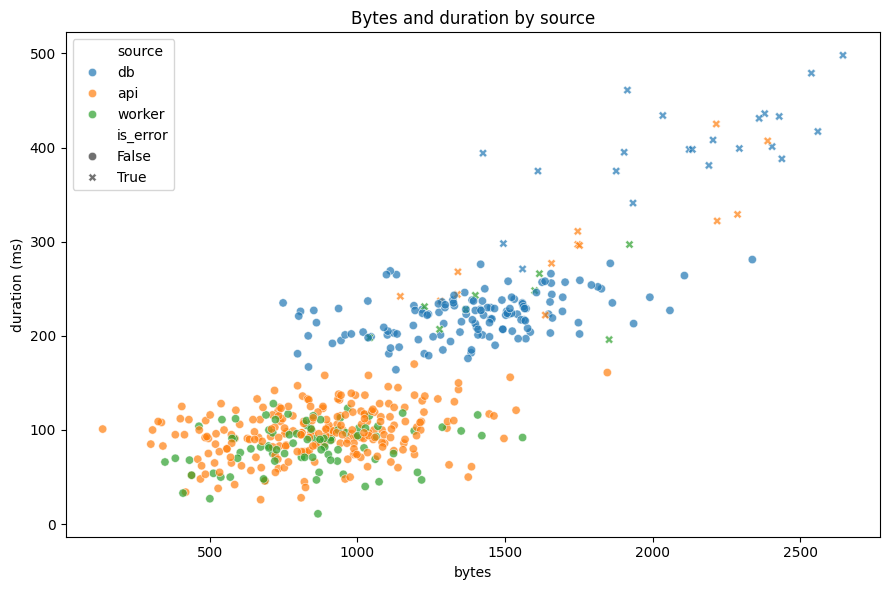

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=large_df,
    x="bytes",
    y="duration_ms",
    hue="source",
    style="is_error",
    alpha=0.7,
)

plt.title("Bytes and duration by source")
plt.xlabel("bytes")
plt.ylabel("duration (ms)")
plt.tight_layout()
plt.show()

**结论：** bytes 与 duration_ms 在整体及各来源内部均呈正相关。
db 的正常请求整体比 api 和 worker 更慢；ERROR 日志多数位于高耗时、
高字节区域。

**限制：** 不同来源具有不同的基础耗时，整体相关性同时受到来源差异影响。
该数据为按预设规则生成的合成数据，相关关系不能证明真实业务中的因果关系。

**下一步：** 在真实数据中按来源和请求类型分层分析，并补充请求复杂度、
数据库访问次数等变量，以排查混杂因素。

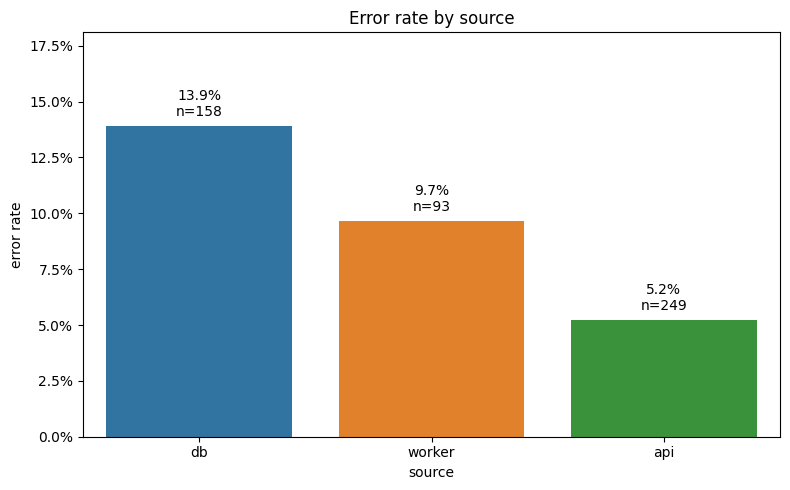

In [45]:
from matplotlib.ticker import PercentFormatter

plot_df = (
    large_source_summary
    .reset_index()
    .sort_values("error_rate", ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="source",
    y="error_rate",
    hue="source",
    legend=False,
)

for index, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        index,
        row["error_rate"] + 0.003,
        (
            f'{row["error_rate"]:.1%}\n'
            f'n={int(row["sample_count"])}'
        ),
        ha="center",
        va="bottom",
    )

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title("Error rate by source")
ax.set_xlabel("source")
ax.set_ylabel("error rate")
ax.set_ylim(0, plot_df["error_rate"].max() * 1.3)

plt.tight_layout()
plt.show()

**结论：** 当前合成样本中，db 错误率最高，为 13.9%；
worker 为 9.7%，api 最低，为 5.2%。

**限制：** 各来源样本量不同，且数据为按预设错误概率生成的合成数据。
当前结果只能验证分析流程，不能证明真实生产服务存在故障。

**下一步：** 使用真实日志扩大时间窗口，并结合历史错误率、请求类型及
业务 SLA 判断差异是否持续存在。

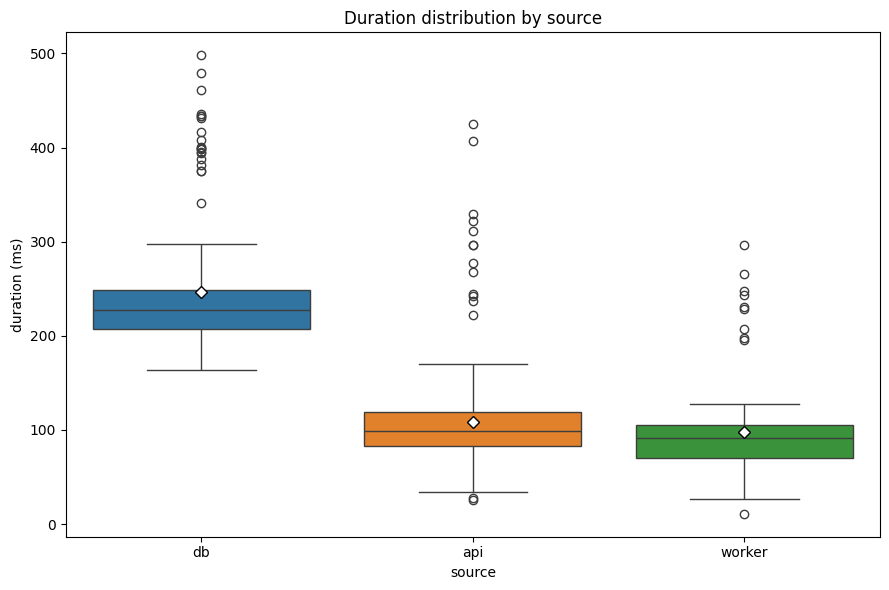

In [46]:
plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    data=large_df,
    x="source",
    y="duration_ms",
    hue="source",
    legend=False,
    whis=1.5,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
    },
)

ax.set_title("Duration distribution by source")
ax.set_xlabel("source")
ax.set_ylabel("duration (ms)")

plt.tight_layout()
plt.show()

In [47]:
boxplot_stats = (
    large_df.groupby("source")["duration_ms"]
    .agg(
        q1=lambda s: s.quantile(0.25),
        median="median",
        q3=lambda s: s.quantile(0.75),
        mean="mean",
    )
    .assign(
        iqr=lambda x: x["q3"] - x["q1"]
    )
)

boxplot_stats.round(2)

,q1,median,q3,mean,iqr
source,,,,,
api,83.0,99.0,119.0,108.17,36.0
db,207.0,227.0,249.0,246.56,42.0
worker,70.0,91.0,105.0,97.59,35.0


**结论：** db 的典型耗时最高，中位数为 227 ms；其中间 50%
数据的跨度为 42 ms，也略高于 api 和 worker。三个来源的均值均高于
中位数，说明少量高耗时记录将均值向上拉。

**限制：** 箱线图中的圆点只是基于 1.5×IQR 规则识别的候选异常，
不能直接认定为系统故障。当前数据也是按预设规则生成的合成数据。

**下一步：** 结合 ERROR、SLA 和时间趋势检查高耗时记录是否持续出现。

In [48]:
hourly_summary = (
    large_df.assign(
        hour=large_df["timestamp"].dt.floor("h")
    )
    .groupby("hour")
    .agg(
        sample_count=("source", "size"),
        error_count=("is_error", "sum"),
        error_rate=("is_error", "mean"),
        median_duration=("duration_ms", "median"),
    )
)

hourly_summary.round(3)

,sample_count,error_count,error_rate,median_duration
hour,,,,
2026-08-20 09:00:00,60,5,0.083,109.0
2026-08-20 10:00:00,60,4,0.067,115.0
2026-08-20 11:00:00,60,5,0.083,103.0
2026-08-20 12:00:00,60,6,0.100,112.5
2026-08-20 13:00:00,60,10,0.167,114.5
2026-08-20 14:00:00,60,6,0.100,127.0
2026-08-20 15:00:00,60,4,0.067,111.0
2026-08-20 16:00:00,60,3,0.050,113.5
2026-08-20 17:00:00,20,1,0.050,163.0


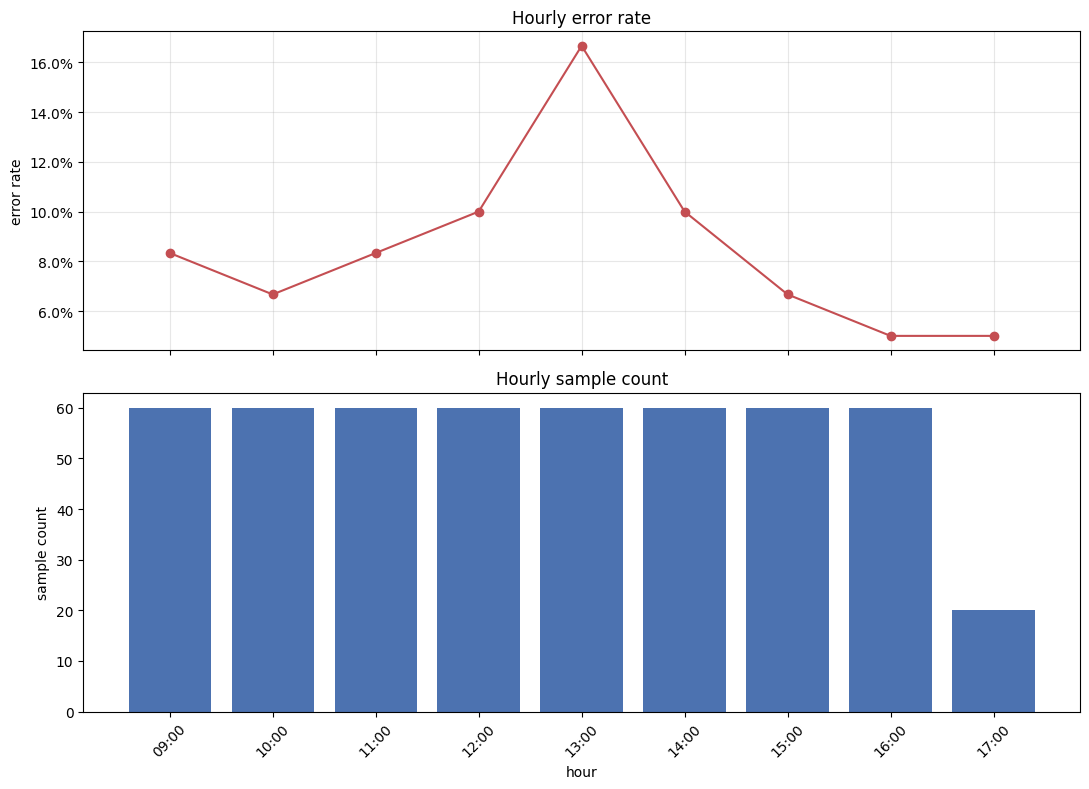

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

hourly_plot = hourly_summary.reset_index()
positions = np.arange(len(hourly_plot))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True,
)

axes[0].plot(
    positions,
    hourly_plot["error_rate"],
    marker="o",
    color="#c44e52",
)

axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title("Hourly error rate")
axes[0].set_ylabel("error rate")
axes[0].grid(alpha=0.3)

axes[1].bar(
    positions,
    hourly_plot["sample_count"],
    color="#4c72b0",
)

axes[1].set_title("Hourly sample count")
axes[1].set_xlabel("hour")
axes[1].set_ylabel("sample count")

axes[1].set_xticks(
    positions,
    hourly_plot["hour"].dt.strftime("%H:%M"),
    rotation=45,
)

plt.tight_layout()
plt.show()

**结论：** 13:00 时段的错误率最高，约为 16.7%，且该时段包含
完整的 60 条样本。其余完整时段错误率约在 5%～10% 之间。

**限制：** 合成数据没有预设时间对错误率的影响，因此 13:00 的高峰
可能来自随机波动。17:00 只有 20 条日志，是不完整时间窗口，不能与
其他完整小时直接比较。

**下一步：** 使用多天真实日志比较同一小时的错误率，并同时展示样本量
或置信区间，判断高峰是否稳定重复出现。

## 管理摘要

当前合成样本中，`bytes` 与 `duration_ms` 呈较强正相关，整体 Pearson
相关系数为 0.818，说明高耗时记录通常也伴随较大的字节数。按来源比较，
db 的错误率最高，为 13.9%（22/158），高于 worker 的 9.7% 和 api 的
5.2%；db 的中位耗时也最高，为 227 ms，值得优先关注。

上述结果来自按预设规则生成的 500 条合成数据，只能用于验证分析流程，
不能证明真实系统存在相同规律。不同来源的基础耗时、请求类型以及业务
上下文都可能影响结果，单个时间窗口的错误率也存在随机波动。

下一步应使用多天真实日志，结合请求类型、SLA、响应状态、数据库访问次数
和请求复杂度进行分层分析，并检查 db 的高错误率和高耗时是否持续出现。